# Phase B — Ön İşleme + 5-Fold CV Split

`labels_v2.csv`'yi temizler, `MultiLabelBinarizer` üretir ve **iterative-stratified 5-fold** CV split'i yazar (PDF "5-cv" şartı). Multi-label dağılımının her fold'da korunmasını sağlar.

**Çıktı:** `DATA_ROOT/mlb.pkl`, `DATA_ROOT/folds/fold_{0..4}_{train,val}.csv`, `cooccurrence_v2.png`

## 0) Kurulum

In [1]:
import os, sys
from pathlib import Path

# --- Yerel ---
CODE_ROOT = Path('../')
DATA_ROOT = Path('../')

# --- Colab (yukaridaki ikisini yorumlayip bunlari ac) ---
# !pip -q install pandas scikit-learn iterative-stratification matplotlib seaborn
# from google.colab import drive
# drive.mount('/content/drive')
# CODE_ROOT = Path('/content/drive/MyDrive/film-genre-project')
# DATA_ROOT = Path('/content/drive/MyDrive/film-genre-project-data')

print('DATA_ROOT =', DATA_ROOT.resolve())
assert (DATA_ROOT / 'labels_v2.csv').exists(), 'labels_v2.csv yok - once Phase A (notebook 07)'

DATA_ROOT = C:\Users\Kerem\Desktop\MakinÖğrenmesi\film-genre-project


## 1) Yükle + temizle

In [2]:
import pandas as pd

TARGET_GENRES = ['Action','Adventure','Animation','Comedy','Crime','Documentary',
                 'Drama','Family','Fantasy','History','Horror','Mystery',
                 'Romance','Science Fiction','Thriller']
POSTERS_DIR = DATA_ROOT / 'posters'

df = pd.read_csv(DATA_ROOT / 'labels_v2.csv', dtype={'tmdb_id': str})
df['genres'] = df['genres'].apply(
    lambda x: [g for g in x.split('|') if g in TARGET_GENRES] if isinstance(x, str) else [])
df = df[df['genres'].map(len) > 0].reset_index(drop=True)

def poster_ok(tid):
    p = POSTERS_DIR / (tid + '.jpg')
    return p.exists() and p.stat().st_size > 0

df['poster_ok'] = df['tmdb_id'].map(poster_ok)
missing = int((~df['poster_ok']).sum())
df = df[df['poster_ok']].drop(columns='poster_ok').reset_index(drop=True)

print('Film:', len(df), '| postersiz/bos dusulen:', missing)
print('Ort tur/film: %.2f' % df['genres'].map(len).mean())
df.head(3)

Film: 23640 | postersiz/bos dusulen: 0
Ort tur/film: 2.18


,tmdb_id,title,genres
0,1978,Stage Fright,[Thriller]
1,2102,Solar Crisis,[Science Fiction]
2,1676,Will Penny,[Romance]


## 2) MultiLabelBinarizer

In [3]:
import pickle
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=TARGET_GENRES)
Y = mlb.fit_transform(df['genres'])
print('Y shape:', Y.shape, '| siniflar:', list(mlb.classes_))
with open(DATA_ROOT / 'mlb.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print('mlb.pkl kaydedildi')

Y shape: (23640, 15) | siniflar: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller']
mlb.pkl kaydedildi


## 3) 5-Fold CV split (iterative-stratified)

In [4]:
import numpy as np
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

N_SPLITS = 5
SEED = 42
folds_dir = DATA_ROOT / 'folds'
folds_dir.mkdir(exist_ok=True)

df_save = df.copy()
df_save['genres'] = df_save['genres'].apply(lambda gs: '|'.join(gs))

mskf = MultilabelStratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
X = np.zeros(len(df))
for i, (tr, va) in enumerate(mskf.split(X, Y)):
    df_save.iloc[tr].to_csv(folds_dir / ('fold_%d_train.csv' % i), index=False)
    df_save.iloc[va].to_csv(folds_dir / ('fold_%d_val.csv' % i), index=False)
    print('fold %d: train=%d  val=%d' % (i, len(tr), len(va)))
print('folds/ yazildi ->', folds_dir)

fold 0: train=18901  val=4739
fold 1: train=18909  val=4731
fold 2: train=18935  val=4705
fold 3: train=18911  val=4729
fold 4: train=18904  val=4736
folds/ yazildi -> ..\folds


## 4) Stratifikasyon kontrolü (her fold val seti dengeli mi)

In [5]:
from collections import Counter

rows = []
for i in range(N_SPLITS):
    va = pd.read_csv(folds_dir / ('fold_%d_val.csv' % i), dtype={'tmdb_id': str})
    va['genres'] = va['genres'].apply(lambda x: x.split('|'))
    c = Counter(g for gs in va['genres'] for g in gs)
    rows.append({g: c.get(g, 0) for g in TARGET_GENRES})

chk = pd.DataFrame(rows, index=['fold%d' % i for i in range(N_SPLITS)]).T
chk['std/mean%'] = (chk.std(axis=1) / chk.mean(axis=1) * 100).round(1)
print('Her fold val setinde tur sayilari (std/mean% kucuk = iyi stratifikasyon):')
print(chk)

Her fold val setinde tur sayilari (std/mean% kucuk = iyi stratifikasyon):
                 fold0  fold1  fold2  fold3  fold4  std/mean%
Action             753    752    753    752    752        0.1
Adventure          601    601    602    601    601        0.1
Animation          600    600    600    600    600        0.0
Comedy             836    835    836    836    835        0.1
Crime              600    600    600    600    600        0.0
Documentary        600    600    600    600    600        0.0
Drama             1331   1332   1332   1331   1332        0.0
Family             600    600    600    600    600        0.0
Fantasy            601    600    600    600    600        0.1
History            600    600    600    600    600        0.0
Horror             600    600    600    600    600        0.0
Mystery            600    600    600    600    600        0.0
Romance            600    600    600    600    600        0.0
Science Fiction    600    600    601    600    600        

## 5) Co-occurrence heatmap (rapor figürü)

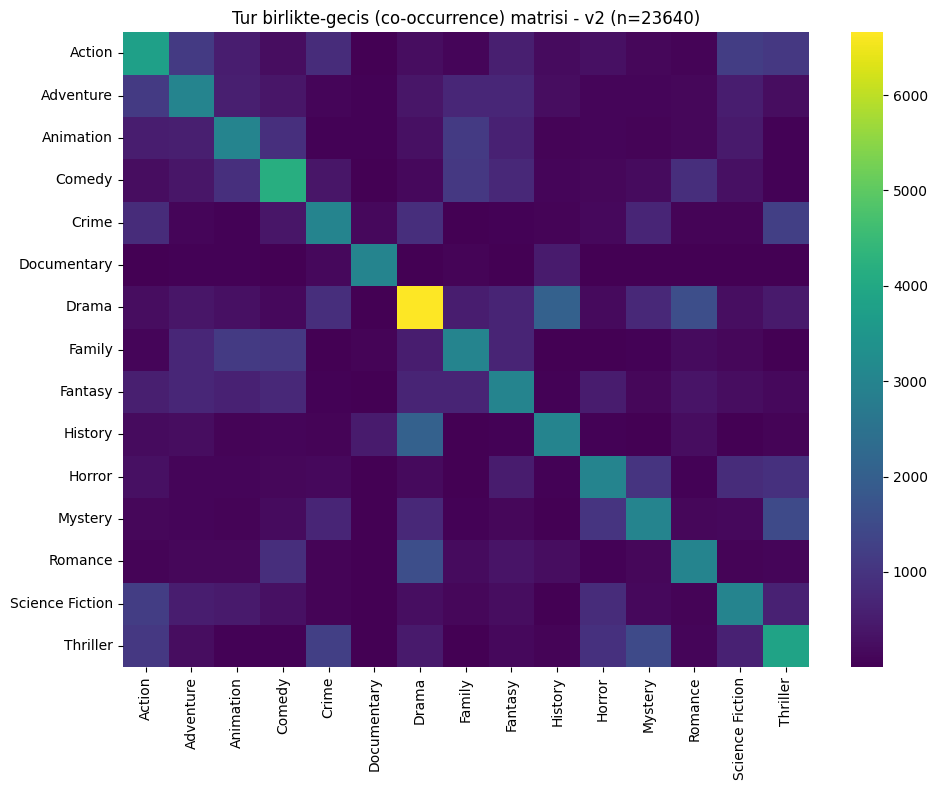

cooccurrence_v2.png kaydedildi


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

idx = {g: i for i, g in enumerate(TARGET_GENRES)}
M = np.zeros((len(TARGET_GENRES), len(TARGET_GENRES)), dtype=int)
for gs in df['genres']:
    for a in gs:
        for b in gs:
            M[idx[a], idx[b]] += 1

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(M, xticklabels=TARGET_GENRES, yticklabels=TARGET_GENRES,
            cmap='viridis', ax=ax)
ax.set_title('Tur birlikte-gecis (co-occurrence) matrisi - v2 (n=%d)' % len(df))
plt.tight_layout()
fig.savefig(DATA_ROOT / 'cooccurrence_v2.png', dpi=120)
plt.show()
print('cooccurrence_v2.png kaydedildi')